<a href="https://colab.research.google.com/github/norrismeg/odw/blob/main/Data_Challenge_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 3 (4 points) -- Intermediate**

Use the data file challenge3.gwf with channel H1:CHALLENGE3.

These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.
The data contain a loud simulated signal with m1 = m2 = 10 solar masses.
1. What is the merger time of this signal?
2. What is the matched-filter SNR of this signal?

In [1]:
! pip install -q lalsuite
! pip install -q gwpy
! pip install -q pycbc
# -- Click "restart runtime" in the runtime menu

In [2]:
# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf

# -- for gwpy
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge3.gwf', channel="H1:CHALLENGE3")

# -- for pycbc
from pycbc import frame
pycbc_strain = frame.read_frame('challenge3.gwf', 'H1:CHALLENGE3')

--2025-05-30 16:42:10--  https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256814830 (245M)
Saving to: ‘challenge3.gwf.2’

challenge3.gwf.2    100%[===================>] 244.92M  20.0MB/s    in 14s     

2025-05-30 16:42:25 (17.1 MB/s) - ‘challenge3.gwf.2’ saved [256814830/256814830]



/usr/local/lib/python3.11/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [3]:
import numpy

import matplotlib.pyplot as plt

from pycbc.waveform import get_td_waveform,get_fd_waveform

1. What is the merger time of this signal?

The sampling rate of the data is: 4096.0 Hz
The duration of the data is: 4096.0 seconds


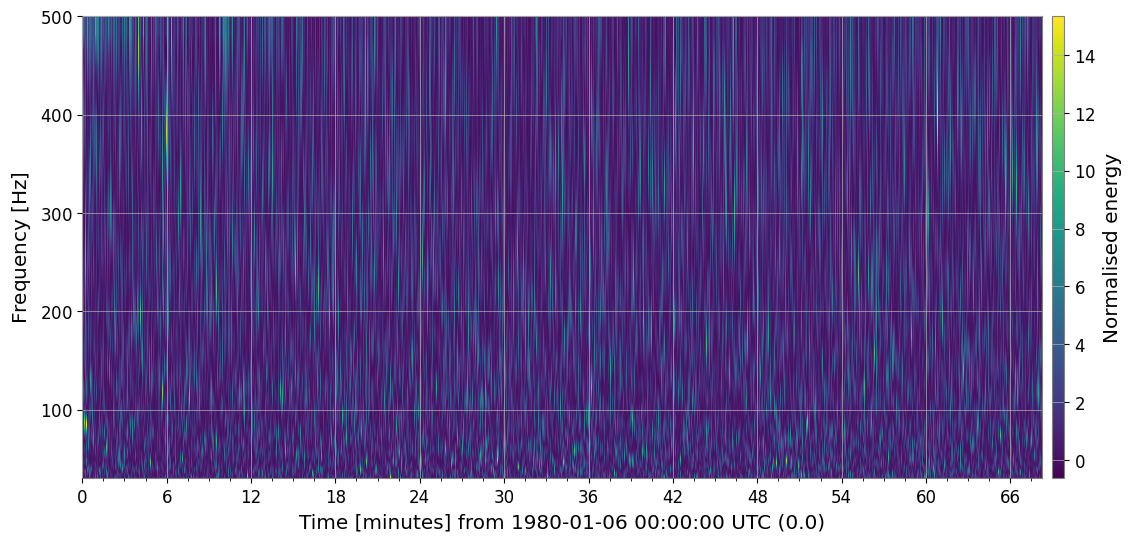

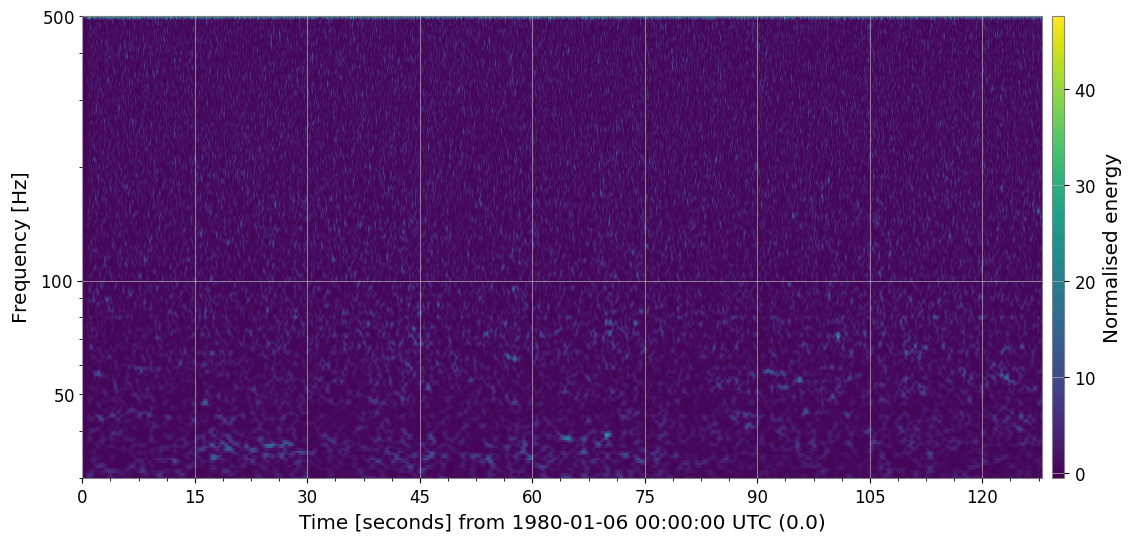

In [4]:
print('The sampling rate of the data is:',1/(pycbc_strain.delta_t),'Hz')
print('The duration of the data is:',len(pycbc_strain)/(1/(pycbc_strain.delta_t)),'seconds')

strain = gwpy_strain.q_transform(frange=(30,500), qrange=(10,20))
plot_q = strain.plot()
plot_q.colorbar(label="Normalised energy")

strain2 = gwpy_strain.q_transform(frange=(30, 500), outseg=(0,128),qrange=(100, 110))
plot_q2 = strain2.plot()
ax = plot_q2.gca()
ax.set_epoch(0)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

2. What is the matched-filter SNR of this signal?

Text(0, 0.5, 'Normalized amplitude')

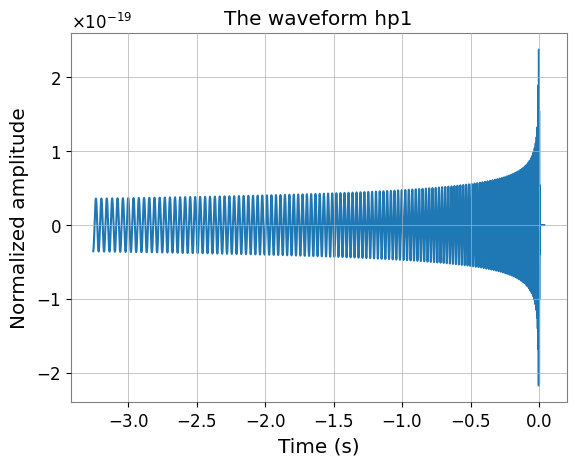

In [5]:
hp1, hc1 = get_td_waveform(approximant='SEOBNRv4_opt',    # m1 = m2 = 10, spin = 0
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/4096,
                         f_lower=25)

plt.figure()
plt.title("The waveform hp1")
plt.plot(hp1.sample_times, hp1)
plt.xlabel('Time (s)')
plt.ylabel('Normalized amplitude')

/usr/local/lib/python3.11/dist-packages/gwpy/plot/axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


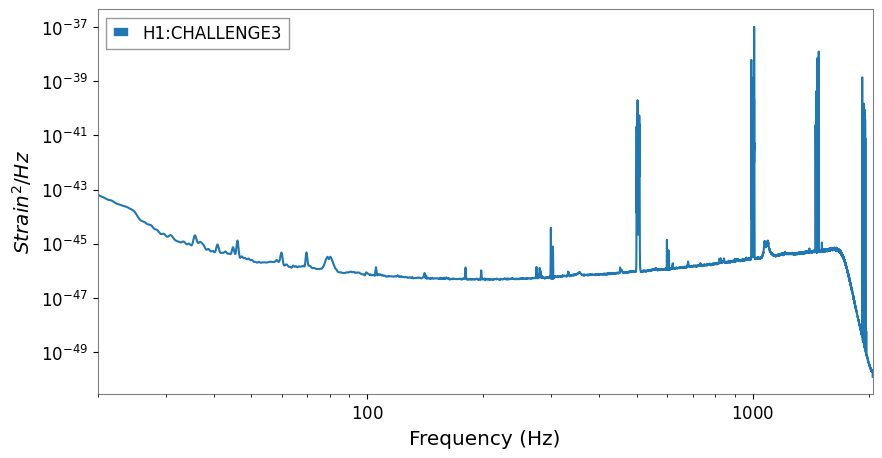

In [6]:
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation

plt.figure(figsize=[10, 5])

# Precondition the data
strain = highpass(pycbc_strain, 15.0)
conditioned = strain.crop(2, 2)

# Estimate the power spectral density of the data
psd2 = conditioned.psd(4)
psd2 = interpolate(psd2, conditioned.delta_f)
psd2 = inverse_spectrum_truncation(psd2, int(2 * conditioned.sample_rate), low_frequency_cutoff=15.0)

plt.plot(psd2.sample_frequencies, psd2, label='H1:CHALLENGE3')

# Nyquist frequency is defined as half the sampling rate
plt.yscale('log')
plt.xscale('log')
#plt.ylim(1e-48, 1e-45)
plt.xlim(20, 2048)
plt.ylabel('$Strain^2 / Hz$')
plt.xlabel('Frequency (Hz)')
plt.grid()
plt.legend()
plt.show()

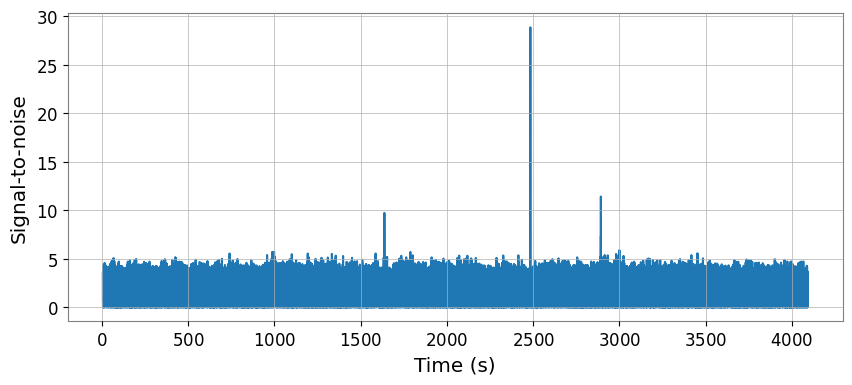

We found a signal at 2483.96728515625s with SNR 28.835145507412857


In [10]:
# Resize the vector to match our data
hp1.resize(len(conditioned))

template1 = hp1.cyclic_time_shift(hp1.start_time)

from pycbc.filter import matched_filter
import numpy

snr1 = matched_filter(template1, conditioned,
                     psd=psd2, low_frequency_cutoff=15)

# Remove time corrupted by the template filter and the psd filter
# We remove 4 seconds at the beginning and end for the PSD filtering
# And we remove 4 additional seconds at the beginning to account for
# the template length (this is somewhat generous for
# so short a template). A longer signal such as from a BNS, would
# require much more padding at the beginning of the vector.
snr1 = snr1.crop(5, 4)

# Why are we taking an abs() here?
# The `matched_filter` function actually returns a 'complex' SNR.
# What that means is that the real portion corresponds to the SNR
# associated with directly filtering the template with the data.
# The imaginary portion corresponds to filtering with a template that
# is 90 degrees out of phase. Since the phase of a signal may be
# anything, we choose to maximize over the phase of the signal.
plt.figure(figsize=[10, 4])
plt.plot(snr1.sample_times, abs(snr1))
plt.ylabel('Signal-to-noise')
plt.xlabel('Time (s)')
plt.show()

peak1 = abs(snr1).numpy().argmax()
snrp1 = snr1[peak1]
time1 = snr1.sample_times[peak1]

print("We found a signal at {}s with SNR {}".format(time1, abs(snrp1)))

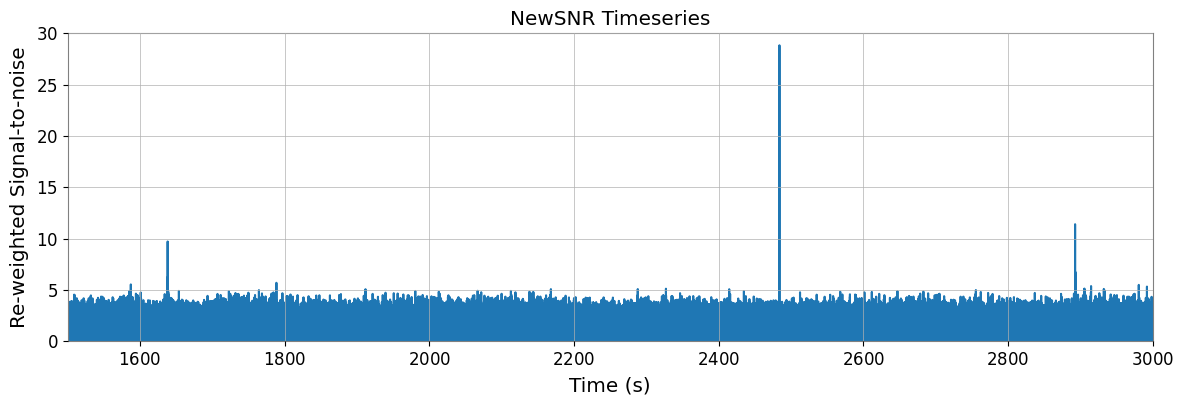

In [22]:
import pylab
from pycbc.vetoes import power_chisq
from pycbc.events.ranking import newsnr

chisq = {}
nbins = 26
chisq_x = power_chisq(hp1, conditioned, nbins, psd2, low_frequency_cutoff=20.0)
chisq_x = chisq_x.crop(5, 4)

dof_x = nbins * 2 - 2
chisq_x /= dof_x


# The rho-hat term above is named "newsnr" here
nsnr_x = newsnr(abs(snr1), chisq_x)

# Plot the new SNR timeseries
pylab.figure(figsize=[14, 4])
pylab.plot(snr1.sample_times, nsnr_x, label='H1')
pylab.title('NewSNR Timeseries')
#pylab.grid()
pylab.xlim(1500,3000)
pylab.ylim(0, 30)
pylab.xlabel('Time (s)')
pylab.ylabel('Re-weighted Signal-to-noise')
pylab.show()

In [20]:
print(isinstance(snr1,numpy.ndarray))
print(isinstance(nsnr_x,numpy.ndarray))

print(nsnr_x.ndim)

False
True
1


In [21]:
peak2 = abs(nsnr_x).argmax()
snrp2 = nsnr_x[peak2]
time2 = snr1.sample_times[peak2]

print("We found a signal at {}s with SNR {}".format(time2, abs(snrp2)))

We found a signal at 2483.96728515625s with SNR 28.835145507412857
